In [ ]:
from data import CARLA_Data as Data
from config import GlobalConfig
import numpy as np
from diskcache import Cache
import torch

tmp_folder = "/tmp" + "/" + "dataset_cache"
shared_dict = Cache(directory=tmp_folder, size_limit=int(50 * 1024**3))

config = GlobalConfig()

config.augment = False
config.use_color_aug = False
config.augment_percentage = 1
config.color_aug_prob = 1
config.seq_len = 2
config.seq_step = 1
config.img_seq_len = 1
config.img_step_size = 1
config.lidar_seq_len = 1
config.trajectory_step_size = 1
config.trajectory_pred_len = 10
config.use_wp_gru = True
config.smooth_route = False
config.use_trajectory_prediction = True
config.use_dataset_pruning = False

config.initialize(
    root_dir=[
        "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
    ]
)

dataset = Data(
    root=config.data_roots,
    config=config,
    shared_dict=shared_dict,
    estimate_class_distributions=config.estimate_class_distributions,
    estimate_sem_distribution=config.estimate_semantic_distribution,
)


Setting:  all
100%|██████████| 3/3 [00:01<00:00,  2.84it/s]
Loading 8152 samples from 3 scenarios
Total amount of routes: 77
Skipped routes: 2
Trainable routes: 75
Maximum dataset size: 8152
Pruned 0 samples (0.0% of dataset)


In [3]:
device = "cuda"
last_feature = None
BZ = 2
loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))
torch.manual_seed(0)
# loader_old = iter(torch.utils.data.DataLoader(dataset_old, batch_size=BZ))


def extract_data(batch):
    return {
        "rgb": batch.get("temporal_rgb", batch["rgb"]).float().to(device),
        # "rgb": batch["rgb"].float().to(device),
        # "lidar_bev": batch.get("temporal_lidar", batch["lidar"]).float().to(device),
        "lidar_bev": batch["lidar"].float().to(device),
        "target_point": batch["target_point"].float().to(device),
        "ego_vel": batch["speed"].float().unsqueeze(1).to(device),
        "command": batch["command"].float().to(device),
    }


def extract_targets(batch):
    return {
        "trajectories": batch["trajectories"].float().to(device),
        "trajectories_mask": batch["trajectories_mask"].float().to(device),
        "target_speed_label": batch["target_speed_twohot"].float().to(device),
        "checkpoint_label": batch["route"][:, : config.predict_checkpoint_len]
        .float()
        .to(device),
        "semantic_label": batch["semantic"].long().to(device),
        "bev_semantic_label": batch["bev_semantic"].long().to(device),
        "depth_label": batch["depth"].float().to(device),
        "center_heatmap_label": batch["center_heatmap"].float().to(device),
        "wh_label": batch["wh"].float().to(device),
        "yaw_class_label": batch["yaw_class"].long().to(device),
        "yaw_res_label": batch["yaw_res"].float().to(device),
        "offset_label": batch["offset"].float().to(device),
        "velocity_label": batch["velocity"].float().to(device),
        "brake_target_label": batch["brake_target"].long().to(device),
        "pixel_weight_label": batch["pixel_weight"].float().to(device),
        "avg_factor_label": batch["avg_factor"].float().to(device),
    }


def unfold_temporaly(data):
    return {k: v.view(4, v.shape[0] // 4, *v.shape[1:]) for k, v in data.items()}


def select(data, i):
    return {k: v[:, i] for k, v in data.items()}

index = 630
# data_point = next(loader)
data_point = {k: torch.tensor(v).unsqueeze(0) for k, v in dataset[index].items()}

In [4]:
# data_point = next(loader)

bev = np.array(config.bev_classes_list)[data_point["bev_semantic"][0].numpy()]
lidar = data_point["lidar"].numpy()[0, :, 0]
traj = data_point["trajectories"][0,].numpy()
mask = data_point["trajectories_mask"][0,].numpy()
traj = traj[np.where(traj.sum(axis=(1, 2)) != 0)]
ch = data_point["center_heatmap"][0, :, 0].numpy()
bb = data_point["bounding_boxes"][0, :, :].numpy()
rgb = data_point["rgb"][0, -1].numpy().transpose(1, 2, 0)
route = data_point["route"][0, :].numpy()

# traj.shape, mask.shape, ch.shape, bb.shape, bev.shape, lidar.shape, rgb.shape

TypeError: Invalid shape (256, 1, 256) for image data

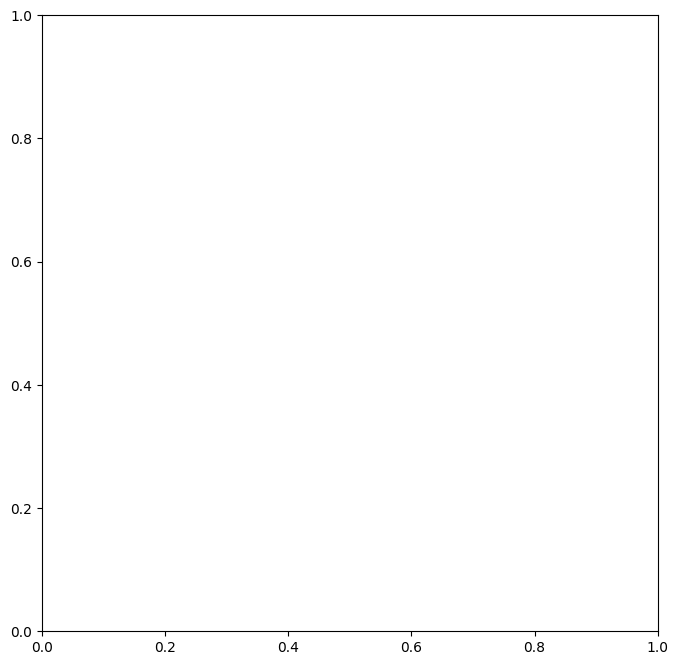

In [ ]:
import matplotlib.pyplot as plt
import cv2

data_point = {k: torch.tensor(v).unsqueeze(0) for k, v in dataset[index].items()}
# index += 1

bev = np.array(config.bev_classes_list)[data_point["bev_semantic"][0].numpy()]
lidar = data_point["lidar"].numpy()[0, :, 0]
traj = data_point["trajectories"][0,].numpy()
mask = data_point["trajectories_mask"][0,].numpy()
traj = traj[np.where(traj.sum(axis=(1, 2)) != 0)]
ch = data_point["center_heatmap"][0, :, 0].numpy()
bb = data_point["bounding_boxes"][0, :, :].numpy()
rgb = data_point["rgb"][0, -1].numpy().transpose(1, 2, 0)

def denormalize_trajectories(trajectory):
    max_xy = np.array([config.trajectory_max_x, config.trajectory_max_y])
    min_xy = np.array([config.trajectory_min_x, config.trajectory_min_y])
    trajectory = trajectory * (max_xy - min_xy)
    trajectory = trajectory + min_xy
    return trajectory

traj = denormalize_trajectories(traj)

traj[:, :, 1] = 255 - traj[:, :, 1]

t = slice(0, -1)
plt.figure(figsize=(8, 8))
# plt.imshow(np.flip(np.rot90(bev[t], k=1), axis=0))
# plt.imshow(np.rot90(bev[t], k=1))
# plt.imshow(bev[t])
# plt.imshow(
#     cv2.resize(ch[t], dsize=(256, 256), interpolation=cv2.INTER_NEAREST), alpha=0.5
# )
# plt.imshow(np.flip(np.rot90(lidar[t], k=1), axis=0), alpha=0.5)
# plt.imshow(lidar[t], alpha=0.5)
# plt.imshow(np.flip(np.rot90(lidar[t], k=1), axis=0), alpha=0.5)
# for box in bb[t]:
#     plt.plot(box[0], box[1], '.', c="green")

# for p in route:
#     print(p)
#     plt.scatter(
#         p[1] * loc_pixels_per_meter + origin[1],
#         p[0] * loc_pixels_per_meter + origin[0],
#     c="r", s=20)

# plt.imshow(np.ones((256,256,3))*255, cmap='gray')

# plt.gca().set_prop_cycle(color=['red', 'green', 'orange', 'blue', 'cyan'])

car = slice(0, -1)
first = True
for i, (car, mask_i) in enumerate(zip(traj[car], mask[car])):
    x = car[np.where(mask_i != -1)][:, 0]  # + origin[0]
    y = car[np.where(mask_i != -1)][:, 1]  # + origin[1]
    plt.scatter(x, y, s=20)
    # for j, (xi, yi) in enumerate(zip(x, y)):
    #     # print(xi, yi)
    #     if first:
    #         plt.scatter(xi, yi, c="r", s=40, label=f"t={j}")
    #         # print(xi, yi)
    #     else:
    #         plt.scatter(xi, yi, c="r", s=20)
    # first = False
    # plt.scatter(x, y, s=8)

# for car in traj[1:2]:
#     for f in car:
#         plt.scatter(f[0], f[1], c="red", s=8)
# plt.scatter(255 // 2, 255 // 2, c="red", s=50, label="ego")
# plt.legend()
plt.axis("off")
plt.show()
# print(mask)
# Do we want to ignore stationary objects?

In [8]:
scale_factor = 1
size_width = int((config.max_y - config.min_y) * config.pixels_per_meter)
size_height = int((config.max_x - config.min_x) * config.pixels_per_meter)
origin_x_ratio = (
    config.max_x / (config.max_x - config.min_x)
    if config.crop_bev and config.crop_bev_height_only_from_behind
    else 1
)
loc_pixels_per_meter = config.pixels_per_meter * scale_factor
origin = (
    (size_width * scale_factor) // 2,
    (origin_x_ratio * size_height * scale_factor) // 2,
)

In [ ]:
import numpy as np

shapes2 = {}
for k, v in data_point.items():
    if isinstance(v, np.ndarray):
        if v.shape == np.array(0).shape:
            continue
        else:
            shapes2[k] = v.shape
            print(f"'{k}': shape[{v.shape}]")

A bounding box sample. This is predicted for all vehicles within the lidar range (I think):
```json
{
    'class': 'ego_car', 
    'extent': [2.3, 0.1, 0.5], 
    'position': [0.0, 0.0, 0.0], 
    'yaw': 0.0,
    'num_points': -1, 
    'distance': -1, 
    'speed': 5.3, 
    'brake': 0.0, 
    'id': 3695, 
    'matrix': [
        [-0.2, -0.3, 0.1, 155.7], 
        [0.2, -0.3, -0.4, 6282.6], 
        [0.3, -3.2, 0.2, 357.1], 
        [0.0, 0.0, 0.0, 1.0]
    ]
}
```
To keep the same shape across batch items, the bounding boxes are padded according to config.max_num_bbs.

In [ ]:
print(data_point.keys())
print()
inputs = extract_data(data_point)
print({k: v.shape for k, v in inputs.items()})
print()
targets = {k: v for k, v in extract_targets(data_point).items()}
print({k: v.shape for k, v in targets.items()})

dict_keys(['rgb', 'lidar', 'target_point', 'target_point_next', 'route', 'brake', 'angle_index', 'target_speed', 'target_speed_twohot', 'semantic', 'bev_semantic', 'depth', 'bounding_boxes', 'center_heatmap', 'wh', 'yaw_class', 'yaw_res', 'offset', 'velocity', 'brake_target', 'pixel_weight', 'avg_factor', 'steer', 'throttle', 'light', 'stop_sign', 'junction', 'speed', 'theta', 'command', 'next_command'])

{'rgb': torch.Size([16, 2, 3, 384, 1024]), 'lidar_bev': torch.Size([16, 2, 1, 256, 256]), 'target_point': torch.Size([16, 2, 2]), 'ego_vel': torch.Size([16, 1, 2]), 'command': torch.Size([16, 2, 6])}

{'target_speed_label': torch.Size([16, 2, 8]), 'checkpoint_label': torch.Size([16, 2, 20, 2]), 'semantic_label': torch.Size([16, 2, 384, 1024]), 'bev_semantic_label': torch.Size([16, 2, 256, 256]), 'depth_label': torch.Size([16, 2, 384, 1024]), 'center_heatmap_label': torch.Size([16, 2, 5, 64, 64]), 'wh_label': torch.Size([16, 2, 2, 64, 64]), 'yaw_class_label': torch.Size([16, 2, 64, 64]

In [1]:
from data import CARLA_Data

from config import GlobalConfig
import torch

config = GlobalConfig()
config.augment = False
config.use_color_aug = False
config.augment_percentage = 1
config.color_aug_prob = 1
config.max_num_trajectories = 20
config.trajectory_pred_len= 10
config.seq_len = 5
config.seq_step = 2
config.img_seq_len = 1
config.img_step_size = 1
config.lidar_seq_len = 1
config.temporal_fusion_layers = 8
config.use_temporal_fusion = True
config.use_recurrent_training = True
config.use_dataset_pruning = True
config.return_temporal_attn_weights = True
config.use_learnable_historic_initialization = True
config.use_trajectory_prediction = True
config.normalize_imagenet = True
config.temporal_fusion_heads = 4
config.initialize(
    root_dir=[
        "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
    ]
)
dataset = CARLA_Data(
    root=config.data_roots,
    config=config,
    estimate_class_distributions=config.estimate_class_distributions,
    estimate_sem_distribution=config.estimate_semantic_distribution,
    # heuristic_pruning=config.use_dataset_pruning,
)

device = "cuda"
BZ = 2  # // config.seq_len
loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))


def extract_data(batch):
    return {
        "rgb": batch.get("temporal_rgb", batch["rgb"]).float().to(device),
        # "rgb": batch["rgb"].float().to(device),
        # "lidar_bev": batch.get("temporal_lidar", batch["lidar"]).float().to(device),
        "lidar_bev": batch["lidar"].float().to(device),
        "target_point": batch["target_point"].float().to(device),
        "ego_vel": batch["speed"].float().unsqueeze(1).to(device),
        # "ego_vel": vel.unsqueeze(1) if (vel:=batch["speed"].float().to(device)).shape.__len__()==1 else vel.unsqueeze(2),
        "command": batch["command"].float().to(device),
    }


def extract_targets(batch):
    return {
        "trajectories_label": batch["trajectories"].float().to(device),
        "trajectories_mask": batch["trajectories_mask"].float().to(device),
        "target_speed_label": batch["target_speed_twohot"].float().to(device),
        "checkpoint_label": batch["route"][:, : config.predict_checkpoint_len]
        .float()
        .to(device),
        "semantic_label": batch["semantic"].long().to(device),
        "bev_semantic_label": batch["bev_semantic"].long().to(device),
        "depth_label": batch["depth"].float().to(device),
        "center_heatmap_label": batch["center_heatmap"].float().to(device),
        "wh_label": batch["wh"].float().to(device),
        "yaw_class_label": batch["yaw_class"].long().to(device),
        "yaw_res_label": batch["yaw_res"].float().to(device),
        "offset_label": batch["offset"].float().to(device),
        "velocity_label": batch["velocity"].float().to(device),
        "brake_target_label": batch["brake_target"].long().to(device),
        "pixel_weight_label": batch["pixel_weight"].float().to(device),
        "avg_factor_label": batch["avg_factor"].float().to(device),
    }


def select(data, i):
    return {k: v[:, i] for k, v in data.items()}


loss_history = []
data_point = next(loader)
index = 650
data_point = {k: torch.tensor(v).unsqueeze(0).repeat_interleave(2,0) for k, v in dataset[index].items()}
# if config.seq_len > 1:
#     data_point = {
#         k: v[:, -1]
#         for k, v in data_point.items()
#         if k not in ["rgb", "lidar_bev", "target_point", "ego_vel", "command"]
#     }

Setting:  all
100%|██████████| 2/2 [00:00<00:00, 57.33it/s]
Loading 5218 samples from 2 scenarios
Total amount of routes: 53
Skipped routes: 1
Trainable routes: 52
Maximum dataset size: 5218
Pruned 0 samples (0.0% of dataset)


In [2]:
from model import LidarCenterNet
features = None

net = LidarCenterNet(config).eval().to(device)
total_params = sum(p.numel() for p in net.parameters())
print(f"Total parameters: {total_params:_}")
# Original: 120_730_298

# Full model: 121_536_186 (+805_888, +0.67%)
# Static hist. init: 121_519_546 (+802_248, +0.67%)

# With motion decoder: 122_244_228 (+1_513_930, +1.25%)

Total parameters: 127_801_229


In [3]:
# Find total parameter count of each top-level module of the network
for module_name, module in net.named_children():
    module_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
    if module_params > 0:
        print(f"Total parameters in {module_name}: {module_params:_} ({module_params / total_params:.2%})")

Total parameters in backbone: 106_566_276 (83.38%)
Total parameters in head: 186_070 (0.15%)
Total parameters in trajectory_head: 802_070 (0.63%)
Total parameters in semantic_decoder: 1_854_727 (1.45%)
Total parameters in bev_semantic_decoder: 37_643 (0.03%)
Total parameters in depth_decoder: 1_852_993 (1.45%)
Total parameters in target_speed_network: 67_848 (0.05%)
Total parameters in join: 9_473_024 (7.41%)
Total parameters in change_channel: 387_328 (0.30%)
Total parameters in checkpoint_decoder: 62_146 (0.05%)
Total parameters in extra_sensor_encoder: 34_048 (0.03%)
Total parameters in temporal_fusor: 6_342_912 (4.96%)


In [4]:
missing_keys, unexpected_keys = net.load_state_dict(
    torch.load(
        "../results/training/stage2/tfpp_s2s1/model_0030.pth", map_location=device, weights_only=True
    ),
    strict=False,
)
print(f"Missing modules:", list(set(missing_keys)))
print(f"Unexpected modules:", list(set(unexpected_keys)))

Missing modules: []
Unexpected modules: []


In [5]:
index += 10

In [6]:
data_point = {k: torch.tensor(v).unsqueeze(0).repeat_interleave(2,0) for k, v in dataset[index].items()}
inputs = extract_data(data_point)
index += 1

with torch.no_grad():
    (
        _,
        pred_target_speed,
        pred_checkpoint,
        pred_semantic,
        pred_bev_semantic,
        pred_depth,
        pred_bounding_box,
        pred_trajectories,
        pred_trajectories_confidence,
        _,
        _,
        _,
        attn_weights,
        # spatial_features,
        # spatiotemporal_features,
    ) = net.forward(
        **inputs,
    )
# features=spatiotemporal_features
def normalize_trajectories(trajectory):
    max_xy = np.array([config.trajectory_max_x, config.trajectory_max_y])
    min_xy = np.array([config.trajectory_min_x, config.trajectory_min_y])
    trajectory = trajectory - min_xy
    trajectory = trajectory / (max_xy - min_xy)
    return trajectory
def denormalize_trajectories(trajectory):
    max_xy = np.array([config.trajectory_max_x, config.trajectory_max_y])
    min_xy = np.array([config.trajectory_min_x, config.trajectory_min_y])
    trajectory = trajectory * (max_xy - min_xy)
    trajectory = trajectory + min_xy
    return trajectory
import numpy as np
sample_pred_trajectory = pred_trajectories[0].detach().cpu().numpy()
sample_pred_confidence = pred_trajectories_confidence[0].softmax(-1).detach().cpu().numpy()
sample_pred_trajectory = sample_pred_trajectory[np.where(sample_pred_confidence[:, 1] > 0.4)]
sample_traj = extract_targets(data_point)['trajectories_label'][0].detach().cpu().numpy()
sample_traj_mask = extract_targets(data_point)['trajectories_mask'][0].detach().cpu().numpy()
sample_traj = sample_traj[np.where(sample_traj_mask.sum(-1) != 0)]
# sample_traj = denormalize_trajectories(sample_traj)
sample_bev = extract_targets(data_point)['bev_semantic_label'][0].detach().cpu().numpy()
bb = data_point["bounding_boxes"]
bev = data_point['bev_semantic']

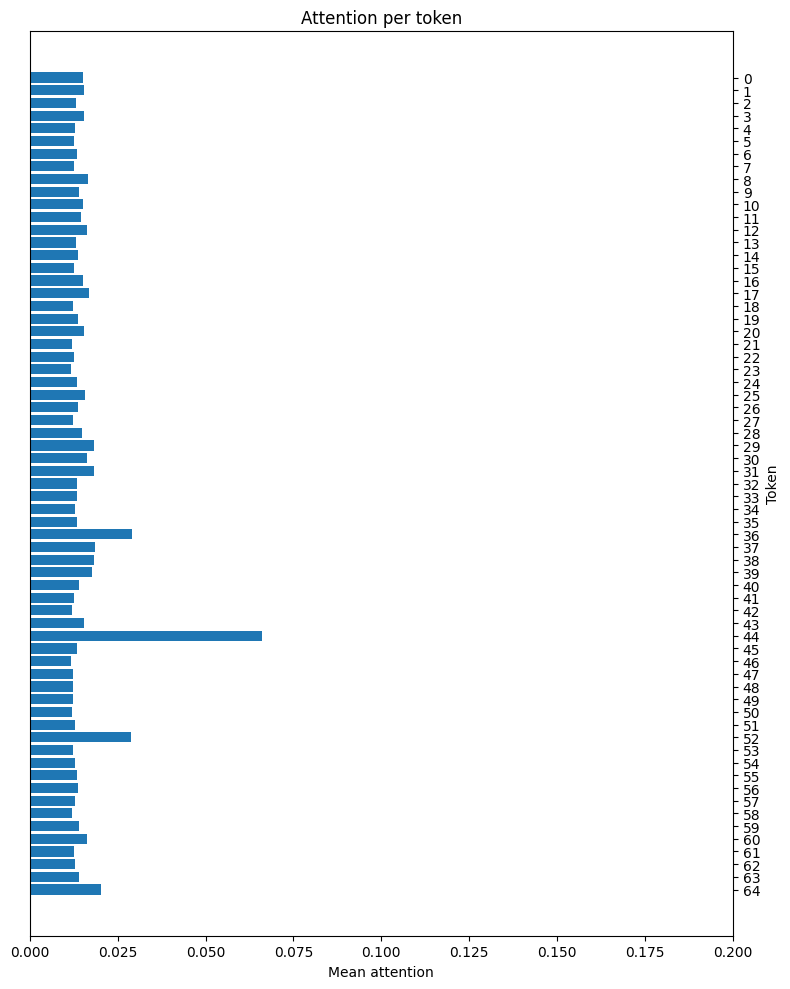

In [7]:
import matplotlib.pyplot as plt
cross_weights = torch.stack([w[0] for w in attn_weights], axis=1)[0].mean(0).mean(0).cpu().detach().numpy()
# horizontal bar plot of a 65x1 matrix
plt.figure(figsize=(8, 10))
plt.title("Attention per token")
plt.xlabel("Mean attention")
plt.ylabel("Token")
plt.barh(np.arange(cross_weights.shape[0])[::-1], cross_weights)
plt.yticks(np.arange(cross_weights.shape[0])[::-1], range(cross_weights.shape[0]))
plt.xlim(0,0.2)
# plt.axhline(28, color='red', linestyle='--')
ax = plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
plt.tight_layout()
plt.show()
# plt.imshow(cross_weights.cpu().detach())

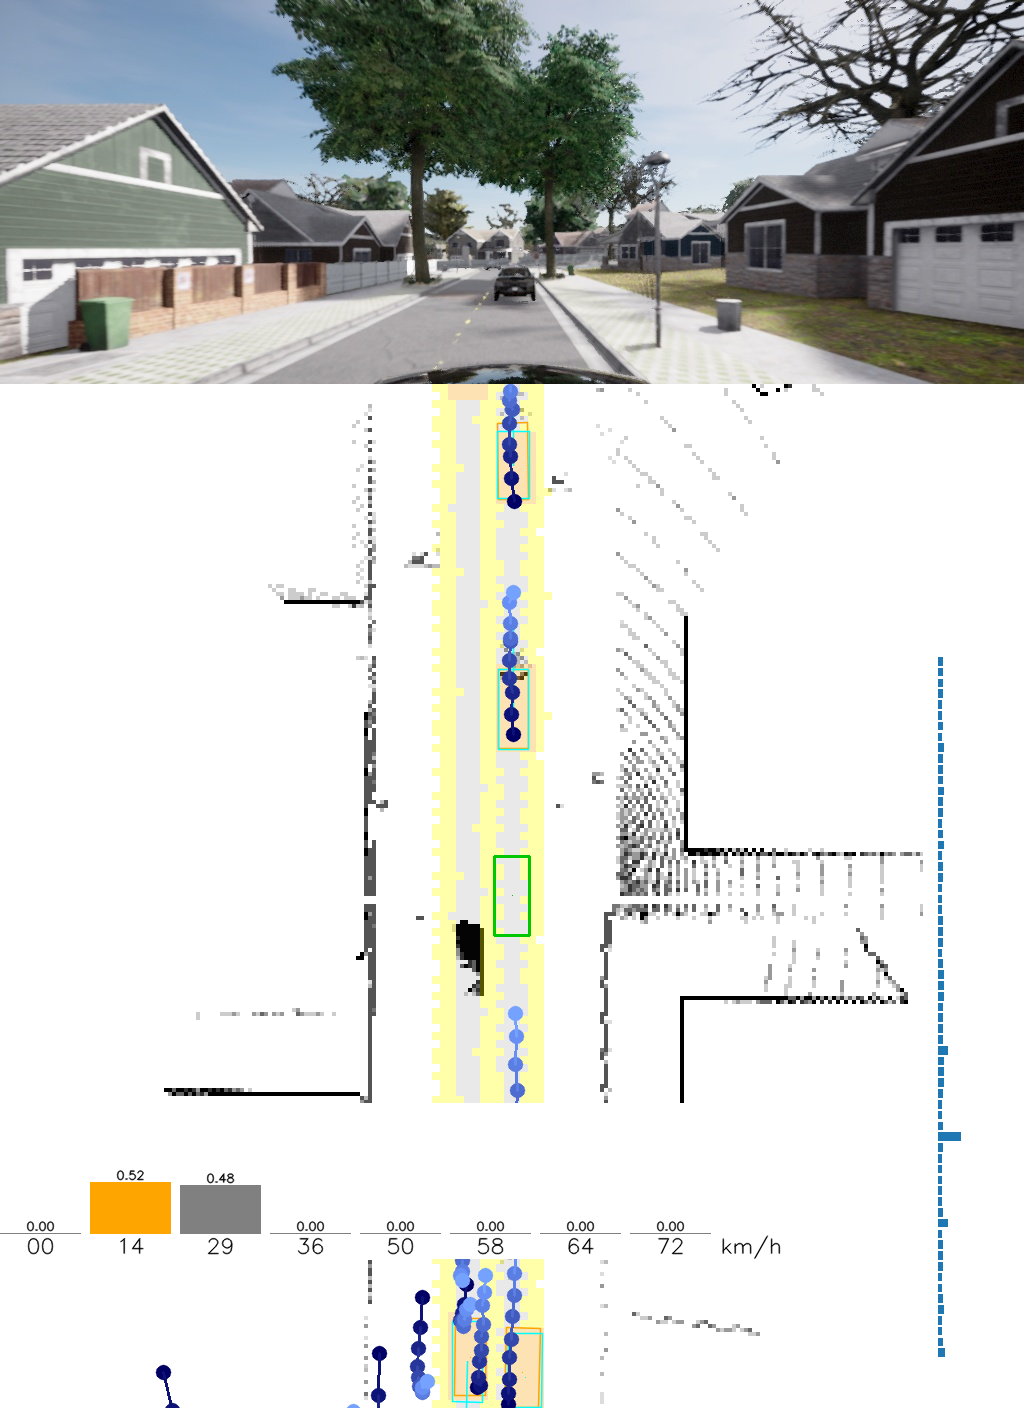

In [8]:
t = -1
rgb = data_point["rgb"][:,-t]
lidar_bev = data_point["lidar"][:,-t]
target_point = data_point["target_point"][:,-t]


image = net.visualize_model(
        save_path=None,
        step=0,
        rgb=rgb,
        lidar_bev=lidar_bev,
        target_point=target_point,
        pred_wp=None,
        target_point_next=None,
        pred_semantic=None,
        pred_bev_semantic=None,
        pred_depth=None,
        pred_checkpoint=None,
        pred_speed=pred_target_speed.softmax(-1),
        pred_target_speed_scalar=None,
        pred_bb=net.convert_features_to_bb_metric(pred_bounding_box),
        pred_trajectories= pred_trajectories,
        pred_trajectory_confidence=pred_trajectories_confidence,
        temporal_attn_weights=attn_weights,
        gt_wp=None,
        gt_checkpoints=None,
        gt_bbs=bb,
        gt_speed=None,
        gt_bev_semantic=bev,
        wp_selected=None,
)
image
# image = np.array(image)

# image.shape

# # import cv2
# # Add figure to image with cv2

# f.canvas.draw()
# img_plot = np.array(f.canvas.renderer.buffer_rgba())[:,:,:3]
# image[-img_plot.shape[0]-1:-1, -img_plot.shape[1]-1:-1, :] = img_plot

# plt.axis('off')
# plt.imshow(image)

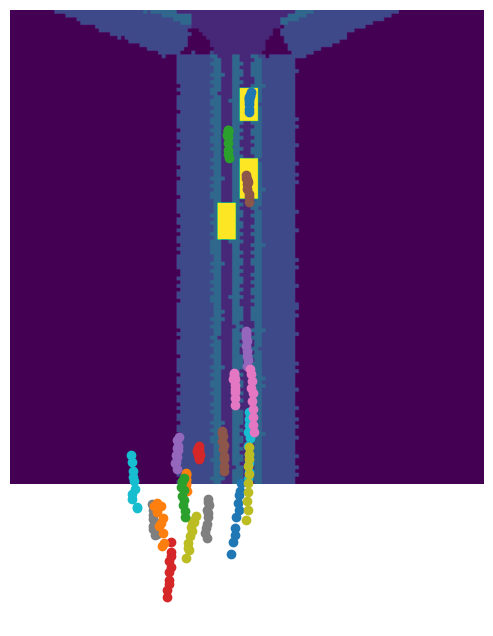

In [140]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.axis('off')
# plt.imshow(np.flip(np.rot90(sample_bev, k=1), axis=0))
plt.imshow(np.rot90(sample_bev, k=1))

for traj in pred_trajectories[-1].detach().cpu().numpy():
    traj = denormalize_trajectories(traj) * np.array([1,-1]) + np.array([0, 255])
    plt.scatter(traj[:, 0], traj[:, 1])
# for traj in sample_traj:
#     plt.scatter(traj[:, 0], traj[:, 1])

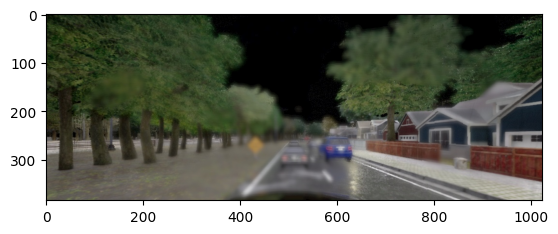

In [27]:
plt.imshow(data_point["rgb"][0, 0].numpy().transpose(1, 2, 0))

In [26]:
data_point["rgb"][0].shape

torch.Size([2, 3, 384, 1024])

In [224]:
(min_x, max_x), (min_y, max_y), (config.max_x, config.min_x)
config.trajectory_min_x = -70
config.trajectory_min_y = -120
config.trajectory_max_x = 305
config.trajectory_max_y = 380

def normalize_trajectory(trajectory):
    max_xy = np.array([config.trajectory_max_x, config.trajectory_max_y])
    min_xy = np.array([config.trajectory_min_x, config.trajectory_min_y])
    trajectory = trajectory - min_xy
    trajectory = trajectory / (max_xy - min_xy)
    return trajectory
normalize(sample_pred_trajectory).max()

0.6945439453125

In [ ]:
sample_pred_trajectory = sample_pred_trajectory - np.array([self.config.max_x, self.config.max_y])
sample_pred_trajectory = sample_pred_trajectory / np.array([self.config.max_x, self.config.max_y])

In [214]:
# Find the min and max value of all points of all trajectories of the whole dataset
min_x = np.inf
max_x = -np.inf
min_y = np.inf
max_y = -np.inf
from tqdm import tqdm
for i in tqdm(range(len(dataset))):
    data_point = dataset[i]

    traj = data_point["trajectories"]
    min_x = min(min_x, traj[:, :, 0].min())
    max_x = max(max_x, traj[:, :, 0].max())
    min_y = min(min_y, traj[:, :, 1].min())
    max_y = max(max_y, traj[:, :, 1].max())
print(f"min_x: {min_x}, max_x: {max_x}, min_y: {min_y}, max_y: {max_y}")

100%|██████████| 4061/4061 [08:43<00:00,  7.76it/s]

min_x: -68.14397630092685, max_x: 305.3775698355173, min_y: -116.92696664008756, max_y: 375.4209310490414


In [3]:
outputs = net(**extract_data(data_point))

(
    _,
    pred_target_speed,
    pred_checkpoint,
    pred_semantic,
    pred_bev_semantic,
    pred_depth,
    pred_bounding_box,
    pred_trajectories,
    pred_trajectories_confidence,
    _,
    _,
    _,
    attn_weights,
) = outputs
[
    o.shape if isinstance(o, torch.Tensor) else "n/a" for o in outputs
]

torch.Size([2, 64, 64, 64])
torch.Size([2, 1512, 8, 8])
torch.Size([2, 1512, 12, 32])

torch.Size([2, 64, 64, 64])
torch.Size([2, 1512, 8, 8])
torch.Size([2, 1512, 12, 32])



['n/a',
 torch.Size([2, 8]),
 torch.Size([2, 10, 2]),
 torch.Size([2, 7, 384, 1024]),
 torch.Size([2, 11, 256, 256]),
 torch.Size([2, 384, 1024]),
 'n/a',
 torch.Size([2, 20, 6, 2]),
 torch.Size([2, 20, 2]),
 'n/a',
 'n/a',
 'n/a',
 'n/a']

In [11]:
from tqdm import tqdm

for batch in tqdm(loader):
    # Select the last seq item
    targets = {
        k: (
            v[:, -1]
            if config.seq_len > 1
            and k not in ["rgb", "lidar_bev", "target_point", "ego_vel", "command", "trajectories", "trajectories_mask"]
            else v
        )
        for k, v in batch.items()
    }
    targets = extract_targets(targets)
    data = extract_data(batch)

    (
        _,
        pred_target_speed,
        pred_checkpoint,
        pred_semantic,
        pred_bev_semantic,
        pred_depth,
        pred_bounding_box,
        pred_trajectories,
        pred_trajectory_confidence,
        _,
        _,
        _,
        attn_weights,
    ) = net.forward(
        **data,
    )
    losses = net.compute_loss(
        pred_target_speed=pred_target_speed,
        pred_checkpoint=pred_checkpoint,
        pred_semantic=pred_semantic,
        pred_bev_semantic=pred_bev_semantic,
        pred_depth=pred_depth,
        pred_bounding_box=pred_bounding_box,
        pred_trajectories=pred_trajectories,
        pred_trajectory_confidence=pred_trajectory_confidence,
        **targets,
    )
    loss = 0
    for k, v in losses.items():
        loss += v
    loss.backward()
    loss_history.append(loss.item())
# (
#     pred_target_speed.shape,
#     pred_checkpoint.shape,
#     pred_semantic.shape,
#     pred_bev_semantic.shape,
#     pred_depth.shape,
#     (len(pred_bounding_box), pred_bounding_box[0].shape),
#     weights,
# )

  3%|▎         | 134/4189 [01:11<35:49,  1.89it/s]


KeyboardInterrupt: 

In [ ]:
from trajectory_head import MotionTransformer

motion_head = MotionTransformer(
    d_model=256, n_layers=2, n_queries=10, future_steps=6
).to(device)
total_params = sum(p.numel() for p in motion_head.parameters())
print(f"Total parameters: {total_params:_}")

Total parameters: 1_587_469


In [ ]:
traj_pred, confidence = motion_head.forward(torch.zeros(2, 65, 256).to(device))
traj_pred.shape, confidence.shape

(torch.Size([2, 10, 6, 2]), torch.Size([2, 10]))

In [ ]:
(
    pred_target_speed.shape,
    pred_checkpoint.shape,
    pred_semantic.shape,
    pred_bev_semantic.shape,
    pred_depth.shape,
    (len(pred_bounding_box), pred_bounding_box[0].shape),
    feature.shape,
)

(torch.Size([2, 8]),
 torch.Size([2, 10, 2]),
 torch.Size([2, 7, 384, 1024]),
 torch.Size([2, 11, 256, 256]),
 torch.Size([2, 384, 1024]),
 (7, torch.Size([2, 5, 64, 64])),
 torch.Size([2, 65, 256]))

### Losses

The loss is an aggregate of all the losses from the different heads used in the model.

#### Main predictions

The main predictions are target speed and checkpoint, so the losses will be:
- `loss_target_speed`
- `loss_checkpoint`

#### Bounding boxes

The bounding box prediction is based on the Center Net implementation (which in this case is based on lidar BEV images, so it's called LidarCenterNet). We have

Bounding box losses:
- `loss_center_heatmap`
- `loss_wh`
- `loss_offset`
- `loss_yaw_class`
- `loss_yaw_res`
- `loss_velocity` is only calculated when using a sequence length of > 1 (either lidar or whole sequence)

There is also functionality for loading future bounding boxes, but this is only enabled for PlanT runs. If we want to predict future trajectories, maybe this could be used for a temporal TF++ too? 

## Loading data

What we want to load is:
- rgb (.png)
- lidar_bev (.lav)
- semantic (.png)
- bev_semantic (.png)
- depth (.png)
- boxes (.json.gz)
- measurements (.json.gz)

In addition, rgb, semantic, bev_semantic and depth have *augmented* versions stored in their own file, which should be applied randomly for every data point.

Another addition, rgb and lidar_bev have temporal versions for loading sequences of them.

### \_\_init\_\_()
In init, we load all of the paths of all files we could possibly want to load, and store them as a sequence (according to seq_len). So we have shapes (size, seq, *) for each data point (size is dataset size).

When we load a file, we need to load `file[i][seq_i]`



In [ ]:
losses.keys()

dict_keys(['loss_target_speed', 'loss_checkpoint', 'loss_semantic', 'loss_bev_semantic', 'loss_depth', 'loss_center_heatmap', 'loss_wh', 'loss_offset', 'loss_yaw_class', 'loss_yaw_res'])

In [ ]:
pred_checkpoint.sub(
    data_point["route"][:4][:, : config.predict_checkpoint_len].to(device)
).abs().mean()

tensor(44.1121, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)

In [ ]:
losses

{'loss_target_speed': tensor(2.3619, device='cuda:0', grad_fn=<DivBackward1>),
 'loss_checkpoint': tensor(44.3316, device='cuda:0', grad_fn=<MeanBackward0>),
 'loss_semantic': tensor(1.9900, device='cuda:0', grad_fn=<NllLoss2DBackward0>),
 'loss_bev_semantic': tensor(2.4694, device='cuda:0', grad_fn=<NllLoss2DBackward0>),
 'loss_depth': tensor(0.3275, device='cuda:0', grad_fn=<MeanBackward0>),
 'loss_center_heatmap': tensor(869.3929, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_wh': tensor(1.8131, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_offset': tensor(0.5133, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_yaw_class': tensor(2.4944, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_yaw_res': tensor(0.0228, device='cuda:0', grad_fn=<DivBackward0>)}

In [ ]:
from trajectory_head import TrajectoryDecoder
import torch


device = "cuda"
motion_head = TrajectoryDecoder(n_dim=256, n_layers=2, n_queries=10, future_steps=2).to(
    device
)
total_params = sum(p.numel() for p in motion_head.parameters())
print(f"Total parameters: {total_params:_}")

traj_pred, confidence = motion_head.forward(torch.zeros(2, 65, 256).to(device))
traj_pred.shape, confidence.shape

Total parameters: 1_585_670


(torch.Size([2, 10, 2, 2]), torch.Size([2, 10, 2]))

In [ ]:
preds = torch.zeros(2, 10, 2).to(device)
mask = torch.zeros(2, 10).to(device)
mask.unsqueeze(2).shape

torch.Size([2, 10, 1])

In [ ]:
from hungarian_loss import HungarianLoss

device = "cuda"
criterion = HungarianLoss()

gt_traj = torch.zeros((2, 10, 2, 2)).to(device)
gt_traj[:, 0] = torch.ones(2, 2)
gt_traj.requires_grad = True

mask = torch.zeros((2, 10, 2)).to(device)

losses = criterion((traj_pred, confidence), gt_traj, mask=mask)
loss = sum(losses.values())
loss, losses

(tensor(0.7892, device='cuda:0', grad_fn=<AddBackward0>),
 {'loss_traj': tensor(0., device='cuda:0', grad_fn=<DivBackward0>),
  'loss_traj_confidence': tensor(0.7892, device='cuda:0', grad_fn=<NllLossBackward0>)})

In [ ]:
pred_traj[1]

tensor([[[-10.,  10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.],
         [ 10., -10.]]], device='cuda:0', requires_grad=True)

In [ ]:
gt_traj = torch.rand((1, 10, 2, 2)).to(device)
gt_traj[:, 3, :, :] = 0.0
gt_traj[:, 3]

tensor([[[0., 0.],
         [0., 0.]]], device='cuda:0')